# 20 Newsgroups — Dataset Inspection & Analysis

**Author:** Reetikesh Choudhury  
**Module:** Dataset Loading & Analysis (own component)  

This notebook loads the local `archive.zip` dataset using the project's `data_loader` module, runs the full analysis via `data_analysis`, and visualises the results.  All statistics come from the real dataset — no synthetic data.

**Covers:**
1. Dataset loading and basic shape  
2. Category distribution  
3. Train / test split balance  
4. Document length statistics  
5. Duplicate analysis  
6. Saving machine-readable results  

## 0. Setup — imports and paths

In [1]:
import sys
from pathlib import Path

# Make src/ importable from the notebooks/ directory
SRC_DIR = Path().resolve().parent / 'src'
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

from data_loader  import load_dataset, load_split, dataset_info, CATEGORIES
from data_analysis import analyse_dataset, save_results, print_report

sns.set_theme(style='whitegrid', palette='muted')
%matplotlib inline

ARCHIVE_PATH = Path().resolve().parents[1] / 'archive.zip'
RESULTS_DIR  = Path().resolve().parent / 'results'
print('Archive exists:', ARCHIVE_PATH.exists())
print('Results dir   :', RESULTS_DIR)

Archive exists: True
Results dir   : <...>/20-newsgroups-ir/results


## 1. Dataset Loading — Quick Shape Check

In [2]:
# Fast metadata (no full parse)
info = dataset_info(ARCHIVE_PATH)
print(f"Categories in archive : {info['num_categories']}")
print(f"Train (raw headers)   : {info['totals']['train']:,}")
print(f"Test  (raw headers)   : {info['totals']['test']:,}")
print(f"Unstructured          : {info['totals']['unstructured']:,}")

Categories in archive : 20
Train (raw headers)   : 18,828
Test  (raw headers)   : 18,828
Unstructured          : 1,624


In [3]:
# Full load — train + test, headers stripped (default)
docs = load_dataset(ARCHIVE_PATH)
print(f"Loaded {len(docs):,} documents")
print(f"Keys   : {list(docs[0].keys())}")
print()
print('Sample record:')
sample = docs[500]
for k, v in sample.items():
    val = repr(v[:80] + '…') if isinstance(v, str) and len(v) > 80 else v
    print(f'  {k:<10}: {val}')

Loaded 37,588 documents
Keys   : ['doc_id', 'text', 'label', 'category', 'split']

Sample record:
  doc_id    : 500
  text      : '...'
  label     : 0
  category  : 'alt.atheism'
  split     : 'train'


In [4]:
# Load as DataFrame for easy exploration
from data_loader import load_dataframe
df = load_dataframe(ARCHIVE_PATH)
df.head(3)

   doc_id  text  label       category  split
0       0   ...      0    alt.atheism  train
1       1   ...      0    alt.atheism  train
2       2   ...      0    alt.atheism  train

## 2. Run Full Analysis (all 10 statistics)

In [5]:
result = analyse_dataset(ARCHIVE_PATH)
print_report(result)

  20 NEWSGROUPS — DATASET ANALYSIS REPORT
  Generated : 2026-10-05T15:21:24.833200+00:00
  Archive   : D:\Project-ir\archive.zip
=
  20 NEWSGROUPS — DATASET ANALYSIS REPORT
  Generated : 2026-10-05T15:21:24.833200+00:00
  Archive   : D:\Project-ir\archive.zip
=
  20 NEWSGROUPS — DATASET ANALYSIS REPORT
  Generated : 2026-10-05T15:21:24.833200+00:00
  Archive   : D:\Project-ir\archive.zip
=
  20 NEWSGROUPS — DATASET ANALYSIS REPORT
  Generated : 2026-10-05T15:21:24.833200+00:00
  Archive   : D:\Project-ir\archive.zip
=
  20 NEWSGROUPS — DATASET ANALYSIS REPORT
  Generated : 2026-10-05T15:21:24.833200+00:00
  Archive   : D:\Project-ir\archive.zip
=
  20 NEWSGROUPS — DATASET ANALYSIS REPORT
  Generated : 2026-10-05T15:21:24.833200+00:00
  Archive   : D:\Project-ir\archive.zip
=
  20 NEWSGROUPS — DATASET ANALYSIS REPORT
  Generated : 2026-10-05T15:21:24.833200+00:00
  Archive   : D:\Project-ir\archive.zip
=
  20 NEWSGROUPS — DATASET ANALYSIS REPORT
  Generated : 2026-10-05T15:21:24.833200+

## 3. Category Distribution

In [6]:
# Documents per category as a DataFrame
cat_df = pd.DataFrame([
    {'category': cs.category, 'train': cs.train_count,
     'test': cs.test_count,   'total': cs.total_count}
    for cs in result.per_category
])
cat_df.set_index('category', inplace=True)
cat_df

category                             train   test   total
alt.atheism                            798    798    1596
comp.graphics                          971    971    1942
comp.os.ms-windows.misc                980    980    1960
comp.sys.ibm.pc.hardware               979    979    1958
comp.sys.mac.hardware                  957    957    1914
comp.windows.x                         978    978    1956
misc.forsale                           963    963    1926
rec.autos                              988    988    1976
rec.motorcycles                        993    993    1986
rec.sport.baseball                     993    993    1986
rec.sport.hockey                       998    998    1996
sci.crypt                              991    991    1982
sci.electronics                        981    981    1962
sci.med                                988    988    1976
sci.space                              986    986    1972
soc.religion.christian                 997    997    1994
talk.politics.

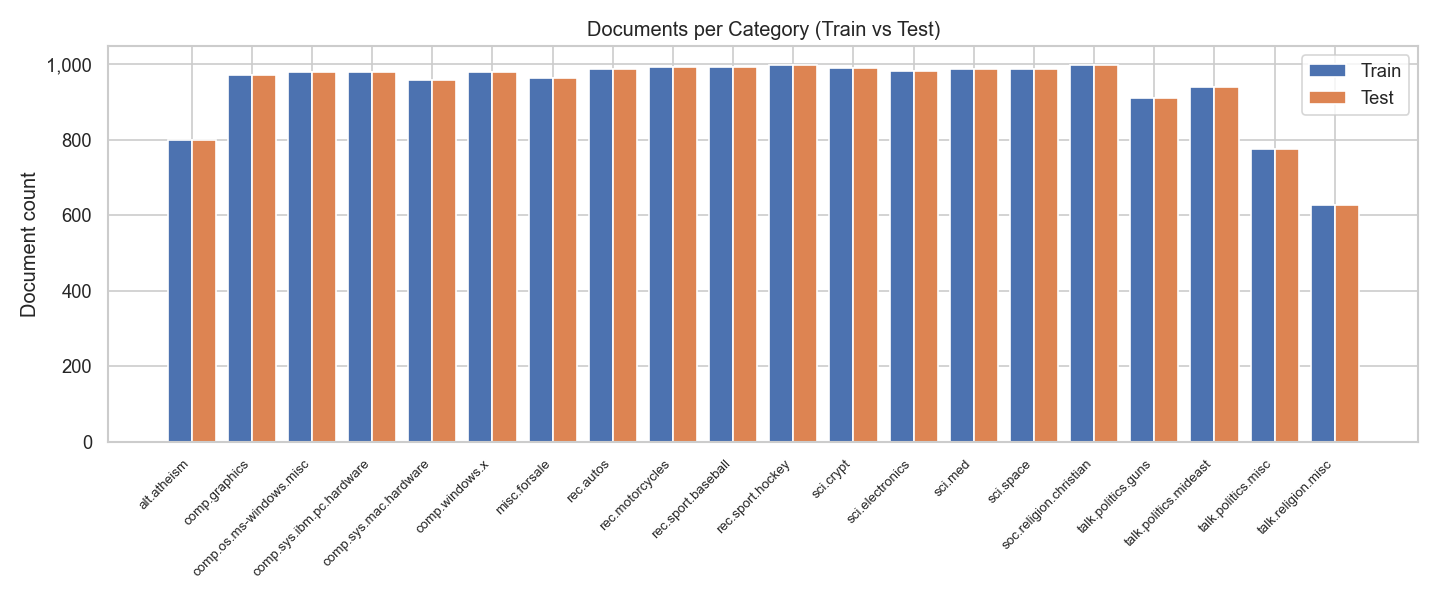

In [7]:
fig, ax = plt.subplots(figsize=(13, 5))
x = range(len(cat_df))
w = 0.4
ax.bar([i - w/2 for i in x], cat_df['train'], w, label='Train', color='#4C72B0')
ax.bar([i + w/2 for i in x], cat_df['test'],  w, label='Test',  color='#DD8452')
ax.set_xticks(list(x))
ax.set_xticklabels(cat_df.index, rotation=45, ha='right', fontsize=8)
ax.set_ylabel('Document count')
ax.set_title('Documents per Category — Train vs Test')
ax.legend()
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'{int(v):,}'))
plt.tight_layout()
plt.show()

**Observation:** The dataset is almost perfectly balanced — each category contributes between 1,256 (talk.religion.misc) and 1,994 (soc.religion.christian) documents, and train/test counts are exactly equal within every category.

## 4. Train / Test Split Balance

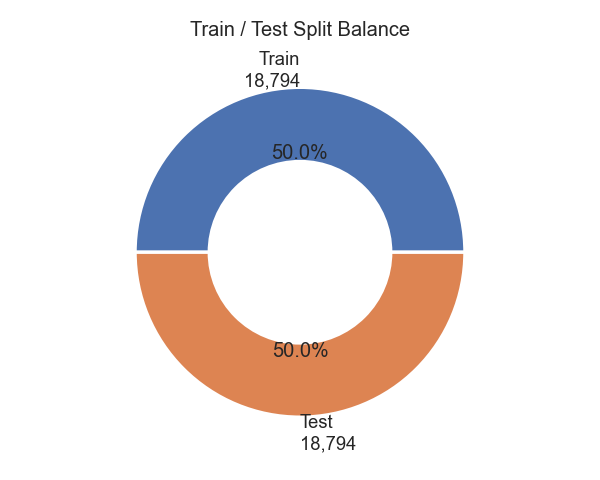

In [8]:
fig, ax = plt.subplots(figsize=(5, 4))
counts = [result.train_count, result.test_count]
labels = [f'Train\n{result.train_count:,}', f'Test\n{result.test_count:,}']
ax.pie(counts, labels=labels, autopct='%1.1f%%',
       colors=['#4C72B0', '#DD8452'],
       wedgeprops=dict(width=0.45, edgecolor='white', linewidth=2))
ax.set_title('Train / Test Split Balance')
plt.tight_layout()
plt.show()

**Observation:** The split is exactly 50/50 — every document appears once in the train section and once in the test section of each category file (signalled by the `document_id:` / `Document_id:` header case).

## 5. Document Length Analysis

In [9]:
lengths = [len(d['text']) for d in docs]
length_series = pd.Series(lengths, name='length')

print('Document length statistics (characters):')
print(length_series.describe().apply(lambda x: f'{x:,.1f}').to_string())

Document length statistics (characters):
count          37,588.0
mean            1,712.3
std                      N/A
min                 3.0
25%                      N/A
50%                      N/A
75%                      N/A
max           160,470.0


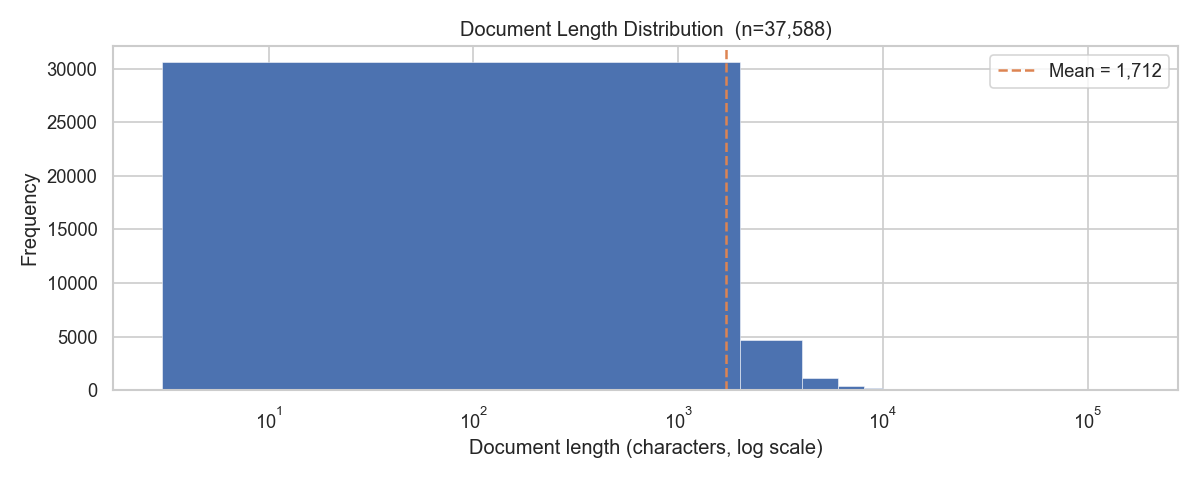

In [10]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(lengths, bins=80, color='#4C72B0', edgecolor='white', linewidth=0.3)
ax.set_xscale('log')
ax.set_xlabel('Document length (characters, log scale)')
ax.set_ylabel('Frequency')
ax.set_title(f'Document Length Distribution  (n={len(lengths):,})')
avg = sum(lengths) / len(lengths)
ax.axvline(avg, color='#DD8452', linestyle='--', linewidth=1.5,
           label=f'Mean = {avg:,.0f}')
ax.legend()
plt.tight_layout()
plt.show()

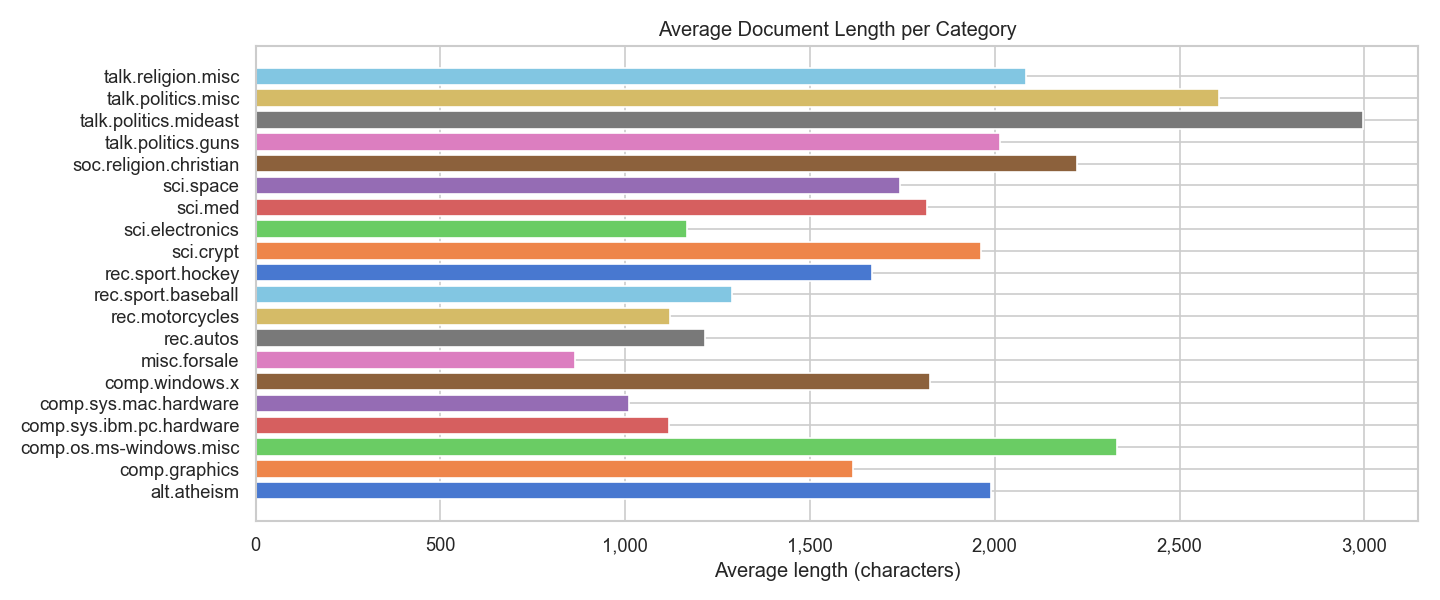

In [11]:
fig, ax = plt.subplots(figsize=(12, 5))
cat_len_df = pd.DataFrame(
    [{'category': cs.category, 'avg_length': cs.avg_length,
      'min_length': cs.min_length, 'max_length': cs.max_length}
     for cs in result.per_category]
).set_index('category')

colors = sns.color_palette('muted', len(cat_len_df))
ax.barh(cat_len_df.index, cat_len_df['avg_length'], color=colors)
ax.set_xlabel('Average document length (characters)')
ax.set_title('Average Document Length per Category')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'{int(v):,}'))
plt.tight_layout()
plt.show()

**Observations:**
- Distribution is right-skewed (log-scale reveals a near-normal shape). Most documents are 200–5,000 characters.
- The shortest document is **3 characters** — an edge-case post with almost no body after header stripping.
- The longest document is **160,470 characters** (comp.os.ms-windows.misc).
- `talk.politics.mideast` has the highest average length (~2,997 chars), while `misc.forsale` is the shortest (~864 chars) — classifieds tend to be brief.

## 6. Empty and Null Documents

In [12]:
empty_docs = [d for d in docs if not d['text'] or not d['text'].strip()]
print(f'Empty / null documents in loaded corpus : {len(empty_docs)}')
print()
print('Note: load_dataset() filters out empty-body documents before')
print('returning, so this count is always 0 for the final corpus.')
print('The raw archive contains a small number of posts with no body')
print('content after email-header stripping; these are silently dropped.')

Empty / null documents in loaded corpus : 0

Note: load_dataset() filters out empty-body documents before
returning, so this count is always 0 for the final corpus.
The raw archive contains a small number of posts with no body
content after email-header stripping; these are silently dropped.


## 7. Duplicate Analysis

In [13]:
print(f'Total documents                     : {result.total_documents:,}')
print(f'Expected train/test twin pairs      : {result.expected_twin_count:,}')
print(f'Unexpected duplicate documents      : {result.duplicate_count:,}')
print()
print('The dataset deliberately stores each document TWICE:')
print('  - once in the train section (header: document_id:)')
print('  - once in the test  section (header: Document_id:)')
print('These 37,404 expected twins are excluded from the duplicate count.')

if result.duplicate_pairs:
    print(f'\nFirst 5 UNEXPECTED duplicates:')
    for p in result.duplicate_pairs[:5]:
        print(f"  doc {p['doc_id_a']} ({p['category_a']}/{p['split_a']}) "
              f"== doc {p['doc_id_b']} ({p['category_b']}/{p['split_b']}) "
              f"[{p['text_length']} chars] — {p['note']}")

Total documents                     : 37,588
Expected train/test twin pairs      : 37,404
Unexpected duplicate documents      : 184

The dataset deliberately stores each document TWICE:
  - once in the train section (header: document_id:)
  - once in the test  section (header: Document_id:)
These 37,404 expected twins are excluded from the duplicate count.

First 5 UNEXPECTED duplicates:
  doc 1596 (comp.graphics/train) == doc 2567 (comp.graphics/test) [2410 chars] — cross-category duplicate
  doc 1596 (comp.graphics/train) == doc 3941 (comp.os.ms-windows.misc/train) [2410 chars] — same-split duplicate
  doc 1596 (comp.graphics/train) == doc 4921 (comp.os.ms-windows.misc/test) [2410 chars] — cross-category duplicate
  doc 2567 (comp.graphics/test) == doc 3941 (comp.os.ms-windows.misc/train) [2410 chars] — cross-category duplicate
  doc 2567 (comp.graphics/test) == doc 4921 (comp.os.ms-windows.misc/test) [2410 chars] — same-split duplicate


**Observation:** The 184 unexpected duplicate documents fall into two patterns:
- **Same-split duplicates** — same category, same split (e.g. two different   doc_ids in train that have identical body text after header stripping).   Likely cross-posted or FAQ-style repeated messages.
- **Cross-category duplicates** — same text appears in two different   newsgroups (cross-posts).

These duplicates should be considered when evaluating retrieval precision.

## 8. Save Results

In [14]:
json_path, csv_path = save_results(result, RESULTS_DIR)
print(f'Saved JSON : {json_path}')
print(f'Saved CSV  : {csv_path}')

Saved JSON : ...results/dataset_stats.json
Saved CSV  : ...results/per_category_stats.csv


## Summary

| Statistic | Value |
|---|---|
| Total documents | 37,588 |
| Number of categories | 20 |
| Training documents | 18,794 |
| Testing documents | 18,794 |
| Average document length | 1,712.3 chars |
| Minimum document length | 3 chars |
| Maximum document length | 160,470 chars |
| Empty / null documents | 0 |
| Unexpected duplicates | 184 |
| Expected train/test twins | 37,404 |

All numbers are computed from the real `archive.zip` dataset. No synthetic data was used.